# ex -1

In [ ]:
import pandas as pd
import numpy as np
data=pd.read_csv("Advertising.csv")
df=pd.DataFrame(data)
df

In [4]:
y=df["Sales"]
x=df.iloc[:,1:4]
print(x.shape)
print(y.shape)
x

(200, 3)
(200,)


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)

from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y_test,ypred))
print("MSE: ",metrics.mean_squared_error(y_test,ypred))
print("R2 score: ",metrics.r2_score(y_test,ypred))
print("Coeffient: ",lr.coef_)
print("Intercept: ",lr.intercept_)
diff=pd.DataFrame({'Actual sales':y_test,"Predicted sales":ypred})
diff

(160, 3)
(160,)
(40, 3)
(40,)
MAE:  1.0402154012924718
MSE:  1.9918855518287906
R2 score:  0.8927605914615384
Coeffient:  [0.0468431  0.17854434 0.00258619]
Intercept:  2.9079470208164295


,Actual sales,Predicted sales
58,23.8,21.735772
40,16.6,16.456938
34,9.5,7.659932
102,14.8,17.892027
184,17.6,18.677307
198,25.5,23.862719
95,16.9,16.336236
4,12.9,13.456492
29,10.5,9.177296
168,17.1,17.360562


# ex-2

In [11]:
import pandas as pd
import numpy as np
data=pd.read_csv("FuelConsumptionCo2.csv")
df=pd.DataFrame(data)
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [12]:
df.drop(columns=["MODELYEAR","MAKE","MODEL","TRANSMISSION"],axis=1,inplace=True)
df

,VEHICLECLASS,ENGINESIZE,CYLINDERS,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,COMPACT,2.0,4,Z,9.9,6.7,8.5,33,196
1,COMPACT,2.4,4,Z,11.2,7.7,9.6,29,221
2,COMPACT,1.5,4,Z,6.0,5.8,5.9,48,136
3,SUV - SMALL,3.5,6,Z,12.7,9.1,11.1,25,255
4,SUV - SMALL,3.5,6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...
1062,SUV - SMALL,3.0,6,X,13.4,9.8,11.8,24,271
1063,SUV - SMALL,3.2,6,X,13.2,9.5,11.5,25,264
1064,SUV - SMALL,3.0,6,X,13.4,9.8,11.8,24,271
1065,SUV - SMALL,3.2,6,X,12.9,9.3,11.3,25,260


In [13]:
y=df["CO2EMISSIONS"]
x=df[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB"]]
x

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB
0,2.0,4,8.5
1,2.4,4,9.6
2,1.5,4,5.9
3,3.5,6,11.1
4,3.5,6,10.6
...,...,...,...
1062,3.0,6,11.8
1063,3.2,6,11.5
1064,3.0,6,11.8
1065,3.2,6,11.3


In [14]:
df.corr(numeric_only=True)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)

from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y_test,ypred))
print("MSE: ",metrics.mean_squared_error(y_test,ypred))
print("R2 score: ",metrics.r2_score(y_test,ypred))
print("Coeffient: ",lr.coef_)
print("Intercept: ",lr.intercept_)
diff=pd.DataFrame({'Actual sales':y_test,"Predicted sales":ypred})
diff

(853, 3)
(853,)
(214, 3)
(214,)
MAE:  16.64682799882323
MSE:  546.2591396903438
R2 score:  0.8653355812644816
Coeffient:  [11.56295409  6.91231122  9.72527271]
Intercept:  65.17950048137254


,Actual sales,Predicted sales
133,274,257.072975
340,200,193.626754
948,196,198.619472
704,161,184.031563
661,320,308.848870
...,...,...
961,301,275.681075
523,184,189.131654
884,274,266.323339
8,267,262.249461


# polynomial linear regression

In [46]:
df=pd.read_csv("polylinearregression.csv")
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [47]:
x=df[["Temperature"]]
y=df["Pressure"]
x

,Temperature
0,0
1,20
2,40
3,60
4,80
5,100


In [48]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
ypred=lr.predict(x)

from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y,ypred))
print("MSE: ",metrics.mean_squared_error(y,ypred))
print("R2 score: ",metrics.r2_score(y,ypred))
print("Coeffient: ",lr.coef_)
print("Intercept: ",lr.intercept_)
diff=pd.DataFrame({'Actual pressure':y,"Predicted pressure":ypred})
diff

MAE:  0.047653333333333346
MSE:  0.002870267555555557
R2 score:  0.690349972603981
Coeffient:  [0.002342]
Intercept:  -0.05086666666666667


,Actual pressure,Predicted pressure
0,0.0002,-0.050867
1,0.0012,-0.004027
2,0.0060,0.042813
3,0.0300,0.089653
4,0.0900,0.136493
5,0.2700,0.183333


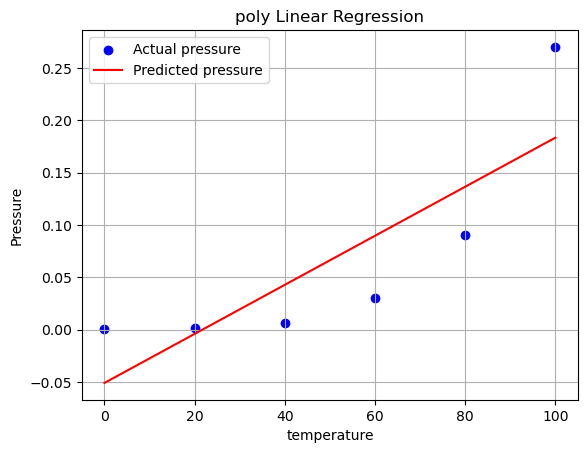

In [49]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color='blue',label='Actual pressure')
plt.plot(x,ypred,color='red',label='Predicted pressure')
plt.xlabel("temperature")
plt.ylabel("Pressure")
plt.title("poly Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)
print(x_poly)

[[1.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [1.00e+00 2.00e+01 4.00e+02 8.00e+03]
 [1.00e+00 4.00e+01 1.60e+03 6.40e+04]
 [1.00e+00 6.00e+01 3.60e+03 2.16e+05]
 [1.00e+00 8.00e+01 6.40e+03 5.12e+05]
 [1.00e+00 1.00e+02 1.00e+04 1.00e+06]]


In [51]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

array([-0.00198889,  0.00724444,  0.00371111,  0.02248889,  0.09865556,
        0.26728889])

In [54]:
from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y,y_pred))
print("MSE: ",metrics.mean_squared_error(y,y_pred))
print("R2 score: ",metrics.r2_score(y,y_pred))

MAE:  0.004899999999994181
MSE:  3.0875185185185205e-05
R2 score:  0.9966691251761722


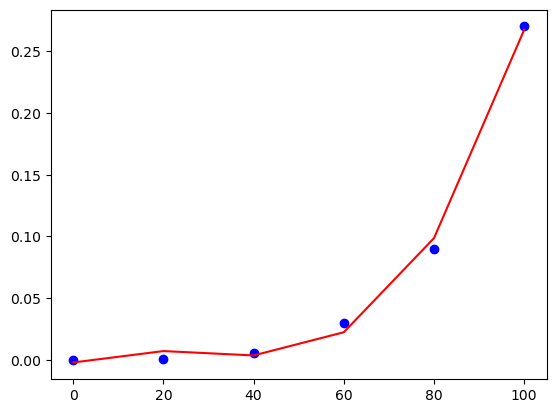

In [55]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color='blue')
plt.plot(x,y_pred,color='red')
plt.show()

In [56]:
df=pd.read_csv("car_data.csv")
df

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14
5,220,4354,12
6,95,2372,25
7,88,2130,27
8,98,2228,24


In [65]:
y=df["MPG"]
x=df[["Horsepower","Weight"]]

from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)
print(x_poly)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y,y_pred))
print("MSE: ",metrics.mean_squared_error(y,y_pred))
print("R2 score: ",metrics.r2_score(y,y_pred))


[[1.0000000e+00 1.3000000e+02 3.5040000e+03 1.6900000e+04 4.5552000e+05
  1.2278016e+07]
 [1.0000000e+00 1.6500000e+02 3.6930000e+03 2.7225000e+04 6.0934500e+05
  1.3638249e+07]
 [1.0000000e+00 1.5000000e+02 3.4360000e+03 2.2500000e+04 5.1540000e+05
  1.1806096e+07]
 [1.0000000e+00 1.4000000e+02 3.4330000e+03 1.9600000e+04 4.8062000e+05
  1.1785489e+07]
 [1.0000000e+00 1.9800000e+02 4.3410000e+03 3.9204000e+04 8.5951800e+05
  1.8844281e+07]
 [1.0000000e+00 2.2000000e+02 4.3540000e+03 4.8400000e+04 9.5788000e+05
  1.8957316e+07]
 [1.0000000e+00 9.5000000e+01 2.3720000e+03 9.0250000e+03 2.2534000e+05
  5.6263840e+06]
 [1.0000000e+00 8.8000000e+01 2.1300000e+03 7.7440000e+03 1.8744000e+05
  4.5369000e+06]
 [1.0000000e+00 9.8000000e+01 2.2280000e+03 9.6040000e+03 2.1834400e+05
  4.9639840e+06]]
(7, 6)
(7,)
(2, 6)
(2,)
MAE:  0.5112449562612882
MSE:  0.5247904852592621
R2 score:  0.9790600840857142


In [70]:
x=[1,2,3,4,5]
y=[1,4,9,16,25]
x=pd.DataFrame(x)
y=pd.Series(y)

from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)
print(x_poly)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y,y_pred))
print("MSE: ",metrics.mean_squared_error(y,y_pred))
print("R2 score: ",metrics.r2_score(y,y_pred))

[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]]
MAE:  4.174438572590589e-15
MSE:  3.1751651435145725e-29
R2 score:  1.0


In [72]:
x=[1,2,3,4,5]
y=[1,8,27,64,125]
x=pd.DataFrame(x)
y=pd.Series(y)

from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)
print(x_poly)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y,y_pred))
print("MSE: ",metrics.mean_squared_error(y,y_pred))
print("R2 score: ",metrics.r2_score(y,y_pred))

[[  1.   1.   1.   1.]
 [  1.   2.   4.   8.]
 [  1.   3.   9.  27.]
 [  1.   4.  16.  64.]
 [  1.   5.  25. 125.]]
MAE:  1.3100631690576847e-14
MSE:  2.8052879865790707e-28
R2 score:  1.0


# CH - 5 
